In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("final_cleaned_data.csv", sep = ';' )
df.head()

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL,Loudness_norm
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,...,Artist 1,Eslabon Armado,Nationality 1,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...,0.849862
1,2,WHERE SHE GOES,Bad Bunny,2023-05-29,0.652,0.800,-4.019,0.061,0.143,0.629,...,Artist 1,Bad Bunny,Nationality 1,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...,0.883423
2,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,...,Artist 1,Yng Lvcas,Nationality 1,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...,0.835301
3,4,Cupid - Twin Ver.,FIFTY FIFTY,2023-05-29,0.783,0.592,-8.332,0.033,0.435,0.000,...,Artist 1,FIFTY FIFTY,Nationality 1,South Korea,Asia,197,197.0,7FbrGaHYVDmfr7KoLIZnQ7,https://open.spotify.com/track/7FbrGaHYVDmfr7K...,0.758318
4,5,un x100to,"Grupo Frontera, Bad Bunny",2023-05-29,0.569,0.724,-4.076,0.047,0.228,0.000,...,Artist 1,Grupo Frontera,Nationality 1,Mexico,Latin-America,196,98.0,6pD0ufEQq0xdHSsRbg9LBK,https://open.spotify.com/track/6pD0ufEQq0xdHSs...,0.881769


In [14]:
# Check the column names in the dataframe
print(df.columns.tolist())
print(f"\nDataframe shape: {df.shape}")

['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm']

Dataframe shape: (467061, 21)


In [15]:
# Add this NEW CELL after loading df (after Cell #VSC-f96637f2) and before aggregation

# =============================================================================
# CREATE COLLABORATION FEATURES (BEFORE AGGREGATION!)
# =============================================================================

print("\n" + "="*70)
print("CREATING COLLABORATION FEATURES")
print("="*70)

# Check if we have the Artist column
print(f"\nAvailable columns: {df.columns.tolist()}")

# Assuming the artist column is 'Artist (Ind.)' or 'Artists'
artist_col = 'Artist (Ind.)' if 'Artist (Ind.)' in df.columns else 'Artists'
print(f"Using artist column: {artist_col}")

# Feature 1: num_artists - Count commas + 1
def count_artists(artist_string):
    """Count total number of artists"""
    if pd.isna(artist_string):
        return 1
    num = str(artist_string).count(',') + 1
    return min(num, 3)  # Cap at 3+

df['num_artists'] = df[artist_col].apply(count_artists)

print(f"\n✓ num_artists created")
print(f"  Distribution:")
print(df['num_artists'].value_counts().sort_index())

# Feature 2: is_collaboration
df['is_collaboration'] = (df['num_artists'] >= 2).astype(int)

print(f"\n✓ is_collaboration created")
print(f"  Collaborations: {df['is_collaboration'].sum()} ({df['is_collaboration'].mean()*100:.1f}%)")
print(f"  Solo artists:   {(df['is_collaboration']==0).sum()} ({(df['is_collaboration']==0).mean()*100:.1f}%)")

# Feature 3: num_featured_artists - Count 'ft.' or 'feat.'
def count_featured_artists(artist_string):
    """Count featured artists"""
    if pd.isna(artist_string):
        return 0
    
    artist_string = str(artist_string).lower()
    
    if 'ft.' in artist_string or 'feat.' in artist_string:
        if 'ft.' in artist_string:
            featured_part = artist_string.split('ft.')[-1]
        else:
            featured_part = artist_string.split('feat.')[-1]
        
        return featured_part.count(',') + 1
    
    return 0

df['num_featured_artists'] = df[artist_col].apply(count_featured_artists)

print(f"\n✓ num_featured_artists created")
print(f"  Songs with featured artists: {(df['num_featured_artists'] > 0).sum()} ({(df['num_featured_artists'] > 0).mean()*100:.1f}%)")
print(f"  Distribution:")
print(df['num_featured_artists'].value_counts().sort_index().head())

# Feature 4: collaboration_combined_strength
print(f"\n⚙️  Calculating collaboration_combined_strength...")

# Calculate artist features
artist_features = df.groupby(artist_col).agg({
    'Rank': ['mean', 'min'],
    'Title': 'nunique'
}).reset_index()

artist_features.columns = ['artist', 'avg_rank', 'best_rank', 'unique_songs']
artist_features['avg_rank_score'] = (201 - artist_features['avg_rank']) / 200

# Calculate hit rate
top50_songs = df[df['Rank'] <= 50].groupby(artist_col)['Title'].nunique().reset_index()
top50_songs.columns = ['artist', 'top50_count']

artist_features = artist_features.merge(top50_songs, on='artist', how='left')
artist_features['top50_count'] = artist_features['top50_count'].fillna(0)
artist_features['hit_rate'] = artist_features['top50_count'] / artist_features['unique_songs']
artist_features['hit_rate'] = artist_features['hit_rate'].fillna(0)

def calculate_collaboration_strength(artists_string, artist_features_df):
    """Calculate combined strength of all artists"""
    if pd.isna(artists_string):
        return 0.0
    
    artists = [a.strip() for a in str(artists_string).split(',')]
    strengths = []
    
    for artist in artists:
        match = artist_features_df[artist_features_df['artist'] == artist]
        if len(match) > 0:
            strength = (
                match['avg_rank_score'].values[0] * 0.5 + 
                match['hit_rate'].values[0] * 0.5
            )
            strengths.append(strength)
    
    return np.mean(strengths) if strengths else 0.0

df['collaboration_combined_strength'] = df[artist_col].apply(
    lambda x: calculate_collaboration_strength(x, artist_features)
)

print(f"✓ collaboration_combined_strength created")
print(f"  Mean:   {df['collaboration_combined_strength'].mean():.4f}")
print(f"  Median: {df['collaboration_combined_strength'].median():.4f}")
print(f"  Max:    {df['collaboration_combined_strength'].max():.4f}")

print("\n" + "="*70)
print("✅ ALL COLLABORATION FEATURES CREATED!")
print("="*70)

print("\n📊 Sample data with collaboration features:")
print(df[['Title', artist_col, 'num_artists', 'is_collaboration', 
          'num_featured_artists', 'collaboration_combined_strength']].head(10))


CREATING COLLABORATION FEATURES

Available columns: ['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm']
Using artist column: Artist (Ind.)

✓ num_artists created
  Distribution:
num_artists
1    466490
2       571
Name: count, dtype: int64

✓ is_collaboration created
  Collaborations: 571 (0.1%)
  Solo artists:   466490 (99.9%)

✓ num_featured_artists created
  Songs with featured artists: 0 (0.0%)
  Distribution:
num_featured_artists
0    467061
Name: count, dtype: int64

⚙️  Calculating collaboration_combined_strength...
✓ collaboration_combined_strength created
  Mean:   0.4922
  Median: 0.4923
  Max:    0.9146

✅ ALL COLLABORATION FEATURES CREATED!

📊 Sample data with collaboration features:
               Title   Artist (Ind.)  nu

In [16]:
# Step 1: Aggregate data by song
song_stats = df.groupby(['id', ]).agg({
    'Rank': 'min',
    'Date': 'nunique'
}).reset_index()
song_stats.columns = ['id', 'best_rank', 'weeks_on_chart']

# Step 2: Calculate scores on aggregated data
song_stats['peak_score'] = (201 - song_stats['best_rank']) / 200 * 100
song_stats['longevity_score'] = np.minimum(song_stats['weeks_on_chart'] / 20, 1.0) * 100

# Step 3: Calculate popularity score
weight_peak = 0.5
weight_longevity = 0.6
song_stats['popularity_score'] = (weight_peak * song_stats['peak_score']) + (weight_longevity * song_stats['longevity_score'])

# Step 4: Create labels on unique songs
#threshold = song_stats['popularity_score'].median()
threshold = song_stats['popularity_score'].quantile(0.7)
song_stats['popularity_label'] = song_stats['popularity_score'].apply(lambda x: 'Popular' if x >= threshold else 'Not Popular')

# Display statistics
print(f"Total unique songs: {len(song_stats)}")
print(f"Threshold: {threshold:.2f}")
print("\nLabel distribution:")
print(song_stats['popularity_label'].value_counts())
print(f"\nPercentage:")
print(song_stats['popularity_label'].value_counts(normalize=True) * 100)

song_stats.head()


Total unique songs: 9161
Threshold: 90.00

Label distribution:
popularity_label
Not Popular    6403
Popular        2758
Name: count, dtype: int64

Percentage:
popularity_label
Not Popular    69.894116
Popular        30.105884
Name: proportion, dtype: float64


,id,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,40,118,80.5,100.0,100.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,108,2,46.5,10.0,29.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,91,14,55.0,70.0,69.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,73,560,64.0,100.0,92.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,61,14,70.0,70.0,77.00,Not Popular


In [17]:
df.head()

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL,Loudness_norm,num_artists,is_collaboration,num_featured_artists,collaboration_combined_strength
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,...,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...,0.849862,1,0,0,0.416023
1,2,WHERE SHE GOES,Bad Bunny,2023-05-29,0.652,0.800,-4.019,0.061,0.143,0.629,...,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...,0.883423,1,0,0,0.749304
2,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,...,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...,0.835301,1,0,0,0.572262
3,4,Cupid - Twin Ver.,FIFTY FIFTY,2023-05-29,0.783,0.592,-8.332,0.033,0.435,0.000,...,Asia,197,197.0,7FbrGaHYVDmfr7KoLIZnQ7,https://open.spotify.com/track/7FbrGaHYVDmfr7K...,0.758318,1,0,0,0.567320
4,5,un x100to,"Grupo Frontera, Bad Bunny",2023-05-29,0.569,0.724,-4.076,0.047,0.228,0.000,...,Latin-America,196,98.0,6pD0ufEQq0xdHSsRbg9LBK,https://open.spotify.com/track/6pD0ufEQq0xdHSs...,0.881769,1,0,0,0.784563


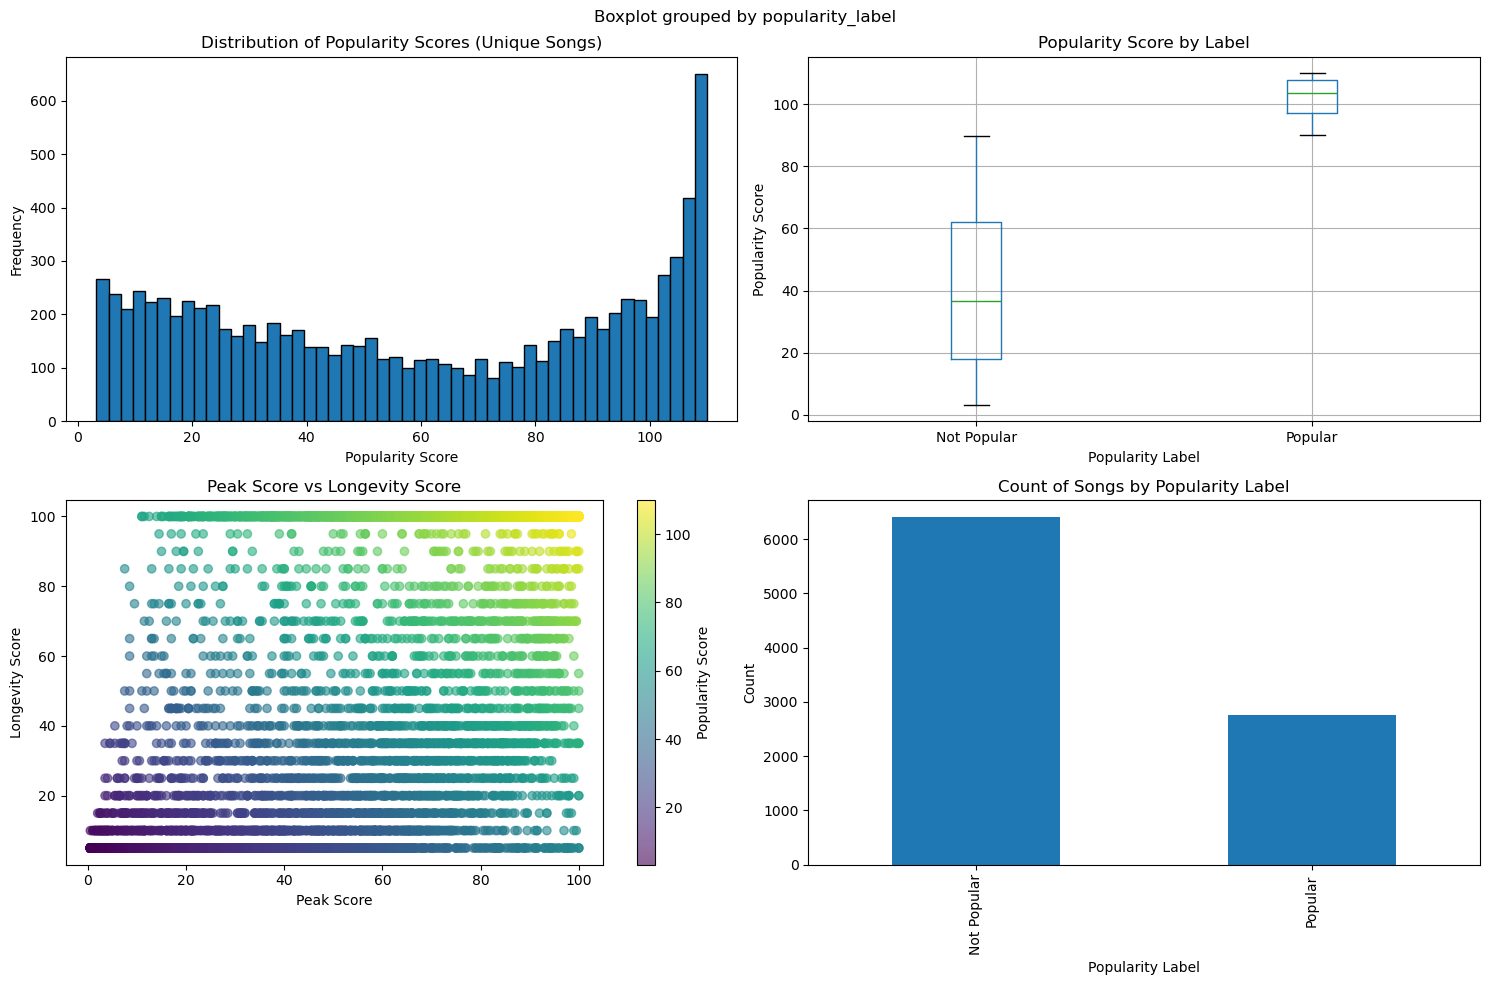

In [18]:
# Visualizations on unique songs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of popularity scores
axes[0, 0].hist(song_stats['popularity_score'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Popularity Scores (Unique Songs)')
axes[0, 0].set_xlabel('Popularity Score')
axes[0, 0].set_ylabel('Frequency')

# Box plot by label
song_stats.boxplot(column='popularity_score', by='popularity_label', ax=axes[0, 1])
axes[0, 1].set_title('Popularity Score by Label')
axes[0, 1].set_xlabel('Popularity Label')
axes[0, 1].set_ylabel('Popularity Score')

# Scatter plot: peak vs longevity
scatter = axes[1, 0].scatter(song_stats['peak_score'], song_stats['longevity_score'], 
                             c=song_stats['popularity_score'], cmap='viridis', alpha=0.6)
axes[1, 0].set_title('Peak Score vs Longevity Score')
axes[1, 0].set_xlabel('Peak Score')
axes[1, 0].set_ylabel('Longevity Score')
plt.colorbar(scatter, ax=axes[1, 0], label='Popularity Score')

# Count plot of labels
song_stats['popularity_label'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Count of Songs by Popularity Label')
axes[1, 1].set_xlabel('Popularity Label')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [19]:
# Merge the labels back to the original dataframe
df_labeled = df.merge(song_stats[['id', 'best_rank', 'weeks_on_chart', 'peak_score', 
                                    'longevity_score', 'popularity_score', 'popularity_label']], 
                      on='id', 
                      how='left')

print(f"Original dataframe shape: {df.shape}")
print(f"Labeled dataframe shape: {df_labeled.shape}")
df_labeled.head()

Original dataframe shape: (467061, 25)
Labeled dataframe shape: (467061, 31)


,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,num_artists,is_collaboration,num_featured_artists,collaboration_combined_strength,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,...,1,0,0,0.416023,1,32,100.0,100.0,110.00,Popular
1,2,WHERE SHE GOES,Bad Bunny,2023-05-29,0.652,0.800,-4.019,0.061,0.143,0.629,...,1,0,0,0.749304,1,11,100.0,55.0,83.00,Not Popular
2,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,...,1,0,0,0.572262,2,73,99.5,100.0,109.75,Popular
3,4,Cupid - Twin Ver.,FIFTY FIFTY,2023-05-29,0.783,0.592,-8.332,0.033,0.435,0.000,...,1,0,0,0.567320,3,59,99.0,100.0,109.50,Popular
4,5,un x100to,"Grupo Frontera, Bad Bunny",2023-05-29,0.569,0.724,-4.076,0.047,0.228,0.000,...,1,0,0,0.784563,1,43,100.0,100.0,110.00,Popular


In [20]:
# Save the complete labeled dataset (all rows with weekly data)
df_labeled.to_csv('spotify_data_labeled_complete.csv', sep=';', index=False)
print(f"✓ Saved complete labeled dataset: {len(df_labeled)} rows")

# Save unique songs with statistics (for ML modeling)
song_stats.to_csv('label_data2.csv', sep=';', index=False)
print(f"✓ Saved song statistics: {len(song_stats)} unique songs")

print("\nDatasets saved successfully!")
print("\nNext steps:")
print("1. Use 'label_data2.csv' for basic statistics and analysis")
print("2. Merge with audio features for ML modeling")
print("3. Or use 'spotify_data_labeled_complete.csv' if you need weekly chart data")

✓ Saved complete labeled dataset: 467061 rows
✓ Saved song statistics: 9161 unique songs

Datasets saved successfully!

Next steps:
1. Use 'label_data2.csv' for basic statistics and analysis
2. Merge with audio features for ML modeling
3. Or use 'spotify_data_labeled_complete.csv' if you need weekly chart data


In [21]:
# Create ML-ready dataset with audio features and labels
# Get one row per song with all features
ml_ready = df.groupby('id').agg({
    'Title': 'first',
    'Artists': 'first',
    'Nationality': 'first',
    'Continent': 'first',
    'Danceability': 'mean',
    'Energy': 'mean',
    'Loudness': 'mean',
    'Speechiness': 'mean',
    'Acousticness': 'mean',
    'Instrumentalness': 'mean',
    'Valence': 'mean',
    '# of Artist': 'first',
    '# of Nationality': 'first',
    'Loudness_norm': 'mean',
    # ADD COLLABORATION FEATURES HERE
    'num_artists': 'first',
    'is_collaboration': 'first',
    'num_featured_artists': 'first',
    'collaboration_combined_strength': 'first'
}).reset_index()

# Merge with song_stats to get labels
ml_ready = ml_ready.merge(song_stats[['id', 'best_rank', 'weeks_on_chart', 'peak_score', 
                                       'longevity_score', 'popularity_score', 'popularity_label']], 
                          on='id', 
                          how='inner')

# Select relevant columns for ML (including collaboration features)
feature_columns = ['id', 'Title', 'Artists', 'Nationality', 'Continent',
                   'Danceability', 'Energy', 'Loudness', 
                   'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 
                   '# of Artist', '# of Nationality', 'Loudness_norm',
                   'num_artists', 'is_collaboration', 'num_featured_artists', 
                   'collaboration_combined_strength',
                   'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score',
                   'popularity_score', 'popularity_label']

ml_ready = ml_ready[feature_columns]

# Save the ML-ready dataset
ml_ready.to_csv('ml_ready_with_features2.csv', sep=';', index=False)
print(f"✓ Saved ML-ready dataset with collaboration features: {len(ml_ready)} unique songs")
print(f"✓ Columns: {ml_ready.columns.tolist()}")

# Verify collaboration features
print("\n📊 Collaboration Features Summary:")
print(f"  num_artists distribution:")
print(ml_ready['num_artists'].value_counts().sort_index())
print(f"\n  Collaborations: {ml_ready['is_collaboration'].sum()} ({ml_ready['is_collaboration'].mean()*100:.1f}%)")
print(f"  Featured artists: {(ml_ready['num_featured_artists'] > 0).sum()} ({(ml_ready['num_featured_artists'] > 0).mean()*100:.1f}%)")

ml_ready.head()

✓ Saved ML-ready dataset with collaboration features: 9161 unique songs
✓ Columns: ['id', 'Title', 'Artists', 'Nationality', 'Continent', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'num_artists', 'is_collaboration', 'num_featured_artists', 'collaboration_combined_strength', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label']

📊 Collaboration Features Summary:
  num_artists distribution:
num_artists
1    9111
2      50
Name: count, dtype: int64

  Collaborations: 50 (0.5%)
  Featured artists: 0 (0.0%)


,id,Title,Artists,Nationality,Continent,Danceability,Energy,Loudness,Speechiness,Acousticness,...,num_artists,is_collaboration,num_featured_artists,collaboration_combined_strength,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,United Kingdom,Europe,0.748,0.627,-6.029,0.064,0.131,...,1,0,0,0.447108,40,118,80.5,100.0,100.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",United States,Anglo-America,0.842,0.578,-6.050,0.138,0.004,...,1,0,0,0.219379,108,2,46.5,10.0,29.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,Canada,Anglo-America,0.353,0.755,-6.276,0.733,0.082,...,1,0,0,0.364929,91,14,55.0,70.0,69.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,United States,Anglo-America,0.352,0.911,-5.230,0.075,0.001,...,1,0,0,0.069397,73,560,64.0,100.0,92.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,United States,Anglo-America,0.620,0.625,-7.438,0.553,0.287,...,1,0,0,0.622402,61,14,70.0,70.0,77.00,Not Popular



📊 DETAILED COLLABORATION FEATURES ANALYSIS

1️⃣  BASIC STATISTICS
----------------------------------------------------------------------
       num_artists  is_collaboration  num_featured_artists  \
count  9161.000000       9161.000000                9161.0   
mean      1.005458          0.005458                   0.0   
std       0.073680          0.073680                   0.0   
min       1.000000          0.000000                   0.0   
25%       1.000000          0.000000                   0.0   
50%       1.000000          0.000000                   0.0   
75%       1.000000          0.000000                   0.0   
max       2.000000          1.000000                   0.0   

       collaboration_combined_strength  
count                      9161.000000  
mean                          0.390067  
std                           0.199069  
min                           0.000000  
25%                           0.224921  
50%                           0.393674  
75%             

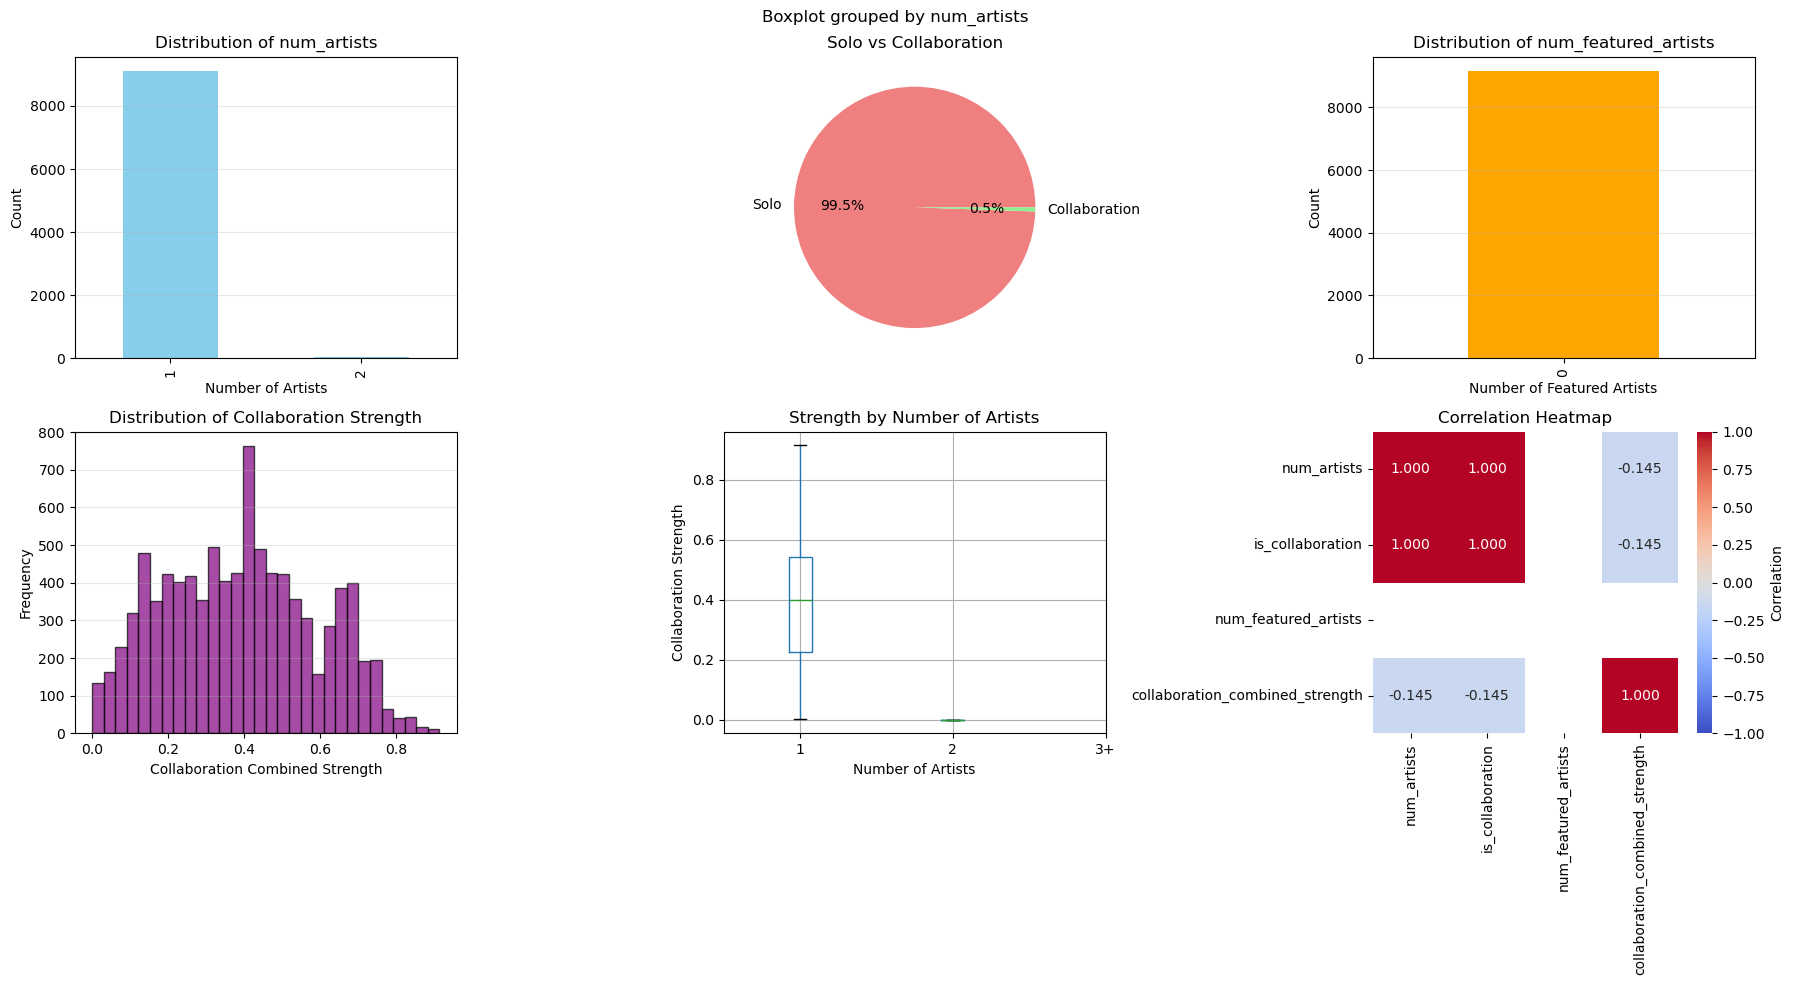


✅ Collaboration features analysis complete!


In [23]:
# Add this NEW CELL after Cell #VSC-3445e0d8 (after saving ml_ready_with_features2.csv)

# =============================================================================
# DETAILED CHECK OF COLLABORATION FEATURES
# =============================================================================

print("\n" + "="*70)
print("📊 DETAILED COLLABORATION FEATURES ANALYSIS")
print("="*70)

# 1. Basic Statistics
print("\n1️⃣  BASIC STATISTICS")
print("-" * 70)
print(ml_ready[['num_artists', 'is_collaboration', 'num_featured_artists', 
                'collaboration_combined_strength']].describe())

# 2. Value Counts for Each Feature
print("\n2️⃣  VALUE DISTRIBUTIONS")
print("-" * 70)

print("\n📈 num_artists distribution:")
print(ml_ready['num_artists'].value_counts().sort_index())
print(f"   Mean: {ml_ready['num_artists'].mean():.2f}")

print("\n📈 is_collaboration distribution:")
collab_counts = ml_ready['is_collaboration'].value_counts()
print(f"   Solo (0):          {collab_counts.get(0, 0)} ({collab_counts.get(0, 0)/len(ml_ready)*100:.1f}%)")
print(f"   Collaboration (1): {collab_counts.get(1, 0)} ({collab_counts.get(1, 0)/len(ml_ready)*100:.1f}%)")

print("\n📈 num_featured_artists distribution:")
print(ml_ready['num_featured_artists'].value_counts().sort_index())
print(f"   Songs with features: {(ml_ready['num_featured_artists'] > 0).sum()} ({(ml_ready['num_featured_artists'] > 0).mean()*100:.1f}%)")

print("\n📈 collaboration_combined_strength distribution:")
print(f"   Min:    {ml_ready['collaboration_combined_strength'].min():.4f}")
print(f"   Max:    {ml_ready['collaboration_combined_strength'].max():.4f}")
print(f"   Mean:   {ml_ready['collaboration_combined_strength'].mean():.4f}")
print(f"   Median: {ml_ready['collaboration_combined_strength'].median():.4f}")
print(f"   Std:    {ml_ready['collaboration_combined_strength'].std():.4f}")

# 3. Sample Data - Show Specific Examples
print("\n3️⃣  SAMPLE DATA EXAMPLES")
print("-" * 70)

print("\n🎵 Solo Artists (num_artists = 1):")
solo_songs = ml_ready[ml_ready['num_artists'] == 1][['Title', 'Artists', 'num_artists', 
                                                       'is_collaboration', 'num_featured_artists',
                                                       'collaboration_combined_strength']].head(5)
print(solo_songs.to_string(index=False))

print("\n🎵 Collaborations with 2 Artists:")
collab_2 = ml_ready[ml_ready['num_artists'] == 2][['Title', 'Artists', 'num_artists', 
                                                     'is_collaboration', 'num_featured_artists',
                                                     'collaboration_combined_strength']].head(5)
print(collab_2.to_string(index=False))

print("\n🎵 Collaborations with 3+ Artists:")
collab_3plus = ml_ready[ml_ready['num_artists'] == 3][['Title', 'Artists', 'num_artists', 
                                                         'is_collaboration', 'num_featured_artists',
                                                         'collaboration_combined_strength']].head(5)
print(collab_3plus.to_string(index=False))

print("\n🎵 Songs with Featured Artists:")
featured = ml_ready[ml_ready['num_featured_artists'] > 0][['Title', 'Artists', 'num_artists',
                                                            'num_featured_artists',
                                                            'collaboration_combined_strength']].head(5)
print(featured.to_string(index=False))

# 4. Check for Missing Values
print("\n4️⃣  MISSING VALUES CHECK")
print("-" * 70)
missing = ml_ready[['num_artists', 'is_collaboration', 'num_featured_artists', 
                    'collaboration_combined_strength']].isnull().sum()
print(missing)

if missing.sum() == 0:
    print("✅ No missing values!")
else:
    print("⚠️  Warning: Missing values detected!")

# 5. Correlation Between Collaboration Features
print("\n5️⃣  CORRELATION BETWEEN FEATURES")
print("-" * 70)
collab_features = ml_ready[['num_artists', 'is_collaboration', 'num_featured_artists', 
                            'collaboration_combined_strength']]
correlation = collab_features.corr()
print(correlation.to_string())

# 6. Cross-tabulation
print("\n6️⃣  CROSS-TABULATION")
print("-" * 70)
print("\nnum_artists vs is_collaboration:")
print(pd.crosstab(ml_ready['num_artists'], ml_ready['is_collaboration']))

print("\nnum_artists vs num_featured_artists:")
print(pd.crosstab(ml_ready['num_artists'], ml_ready['num_featured_artists']))

# 7. Top Collaborations by Strength
print("\n7️⃣  TOP 10 COLLABORATIONS BY COMBINED STRENGTH")
print("-" * 70)
top_collabs = ml_ready[ml_ready['is_collaboration'] == 1].nlargest(10, 'collaboration_combined_strength')[
    ['Title', 'Artists', 'num_artists', 'collaboration_combined_strength']
]
print(top_collabs.to_string(index=False))

# 8. Visualizations
print("\n8️⃣  CREATING VISUALIZATIONS...")
print("-" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: num_artists distribution
ml_ready['num_artists'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of num_artists')
axes[0, 0].set_xlabel('Number of Artists')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: is_collaboration pie chart
ml_ready['is_collaboration'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%',
                                                  labels=['Solo', 'Collaboration'], colors=['lightcoral', 'lightgreen'])
axes[0, 1].set_title('Solo vs Collaboration')
axes[0, 1].set_ylabel('')

# Plot 3: num_featured_artists distribution
ml_ready['num_featured_artists'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='orange')
axes[0, 2].set_title('Distribution of num_featured_artists')
axes[0, 2].set_xlabel('Number of Featured Artists')
axes[0, 2].set_ylabel('Count')
axes[0, 2].grid(axis='y', alpha=0.3)

# Plot 4: collaboration_combined_strength histogram
axes[1, 0].hist(ml_ready['collaboration_combined_strength'], bins=30, edgecolor='black', color='purple', alpha=0.7)
axes[1, 0].set_title('Distribution of Collaboration Strength')
axes[1, 0].set_xlabel('Collaboration Combined Strength')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 5: Boxplot - collaboration_combined_strength by num_artists
ml_ready.boxplot(column='collaboration_combined_strength', by='num_artists', ax=axes[1, 1])
axes[1, 1].set_title('Strength by Number of Artists')
axes[1, 1].set_xlabel('Number of Artists')
axes[1, 1].set_ylabel('Collaboration Strength')
plt.sca(axes[1, 1])
plt.xticks([1, 2, 3], ['1', '2', '3+'])

# Plot 6: Correlation heatmap
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[1, 2],
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

print("\n✅ Collaboration features analysis complete!")
print("="*70)

In [22]:
# Check if Nationality and Continent columns exist
print("Available columns:", df.columns.tolist())
print("\nSample data:")
print(df[['id', 'Title', 'Nationality', 'Continent']].head())

Available columns: ['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm', 'num_artists', 'is_collaboration', 'num_featured_artists', 'collaboration_combined_strength']

Sample data:
                       id              Title  Nationality      Continent
0  3qQbCzHBycnDpGskqOWY0E    Ella Baila Sola       Mexico  Latin-America
1  7ro0hRteUMfnOioTFI5TG1     WHERE SHE GOES  Puerto Rico  Latin-America
2  2UW7JaomAMuX9pZrjVpHAU    La Bebe - Remix       Mexico  Latin-America
3  7FbrGaHYVDmfr7KoLIZnQ7  Cupid - Twin Ver.  South Korea           Asia
4  6pD0ufEQq0xdHSsRbg9LBK          un x100to       Mexico  Latin-America
